# Hasil Aplikasi
# https://t7fqkvcqvlww9inpxuubnx.streamlit.app/

# Modeling Identifikasi Suara Buka Tutup

In [26]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import sounddevice as sd
import soundfile as sf
from IPython.display import Audio, display
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
metadata_path = "data_preprocessed/metadata.csv"
df = pd.read_csv(metadata_path)
print(df.head())


   split  label                                  file_path
0  train   buka    data_preprocessed\train\buka\buka_1.wav
1  train   buka    data_preprocessed\train\buka\buka_2.wav
2  train  tutup  data_preprocessed\train\tutup\tutup_1.wav
3  train  tutup  data_preprocessed\train\tutup\tutup_2.wav
4    val   buka      data_preprocessed\val\buka\buka_1.wav


In [29]:
def extract_features(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # ambil rata‑rata per koefisien
    mfcc_mean = np.mean(mfcc, axis=1)
    return mfcc_mean

features = []
labels = []

for idx, row in df.iterrows():
    feat = extract_features(row["file_path"])
    features.append(feat)
    labels.append(row["label"])

X = np.array(features)
y = np.array(labels)
print("Shape fitur:", X.shape, "Shape label:", y.shape)


Shape fitur: (8, 13) Shape label: (8,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Jumlah train:", X_train.shape[0], "Jumlah test:", X_test.shape[0])


Jumlah train: 6 Jumlah test: 2


In [31]:
knn = KNeighborsClassifier(n_neighbors=3)  # kamu bisa ubah nilai k
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [32]:
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Akurasi test set: {:.4f}".format(acc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Akurasi test set: 0.5000

Classification Report:
              precision    recall  f1-score   support

        buka       0.00      0.00      0.00         1
       tutup       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Confusion Matrix:
[[0 1]
 [0 1]]


c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Jordan\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [33]:
model_path = "saved_models/knn_buka_tutup_model.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(knn, model_path)
print("Model disimpan di:", model_path)


Model disimpan di: saved_models/knn_buka_tutup_model.pkl


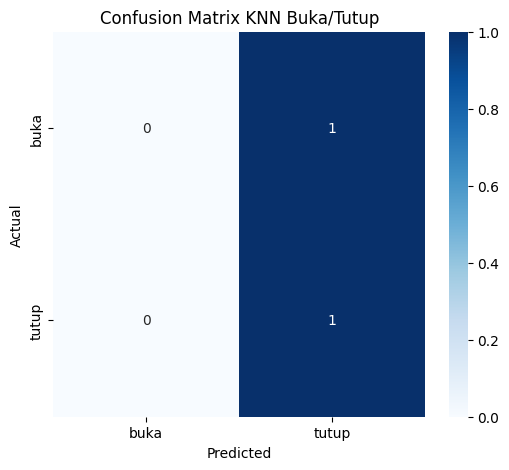

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix KNN Buka/Tutup')
plt.show()
